# DeepTrace - Threat Scoring Engine

This notebook combines anomaly detection and behavioral learning to produce a unified threat score for every network flow.

The scoring engine integrates:

- Isolation Forest
- Transformer Behavioral Model

Outputs include:

- Threat Score (0–100)
- Risk Level
- Confidence
- Recommended Response

In [30]:
import os
import joblib
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch import nn

In [2]:
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cpu


In [3]:
iso_forest = joblib.load("/content/isolation_forest.pkl")

In [4]:
class DeepTraceTransformer(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Linear(49, 64)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64,
            nhead=4,
            dim_feedforward=256,
            dropout=0.2,
            activation="gelu",
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )

        self.classifier = nn.Sequential(
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        x = x.mean(dim=1)
        return self.classifier(x)

In [6]:
transformer = DeepTraceTransformer().to(DEVICE)

transformer.load_state_dict(
    torch.load(
        "/content/best_transformer_model.pth",
        map_location=DEVICE
    )
)

transformer.eval()

print("Transformer model loaded successfully!")

Transformer model loaded successfully!


In [8]:
print("Isolation Forest:", type(iso_forest))
print("Transformer:", type(transformer))

Isolation Forest: <class 'sklearn.ensemble._iforest.IsolationForest'>
Transformer: <class '__main__.DeepTraceTransformer'>


In [9]:
FEATURES_PATH = "/content/deeptrace_features_FINAL.csv"
LABELS_PATH = "/content/deeptrace_binary_labels_FINAL.csv"

X = pd.read_csv(FEATURES_PATH)
y = pd.read_csv(LABELS_PATH).squeeze()

print("Features Shape :", X.shape)
print("Labels Shape   :", y.shape)

X.head()

Features Shape : (239480, 49)
Labels Shape   : (239480,)


,department,role,office_location,device,network_type,authentication,event_type,application,resource,risk_baseline,...,upload_count,database_query_count,file_access_count,admin_action_count,powershell_execution_count,is_privileged_user,is_admin,remote_access,high_risk_event,foreign_login
0,1.0,0.45,0.8,0.25,0.0,1.000000,0.500000,0.03125,0.045455,0.5,...,0.0,0.1875,0.0,0.230769,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.45,0.8,0.25,0.0,0.333333,0.000000,0.00000,0.409091,0.5,...,0.0,0.1875,0.0,0.230769,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.45,0.8,0.25,0.0,1.000000,0.083333,0.90625,0.636364,0.5,...,0.0,0.1875,0.0,0.230769,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.45,0.8,0.25,0.0,0.000000,0.083333,0.21875,0.090909,0.5,...,0.0,0.1875,0.0,0.230769,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.45,0.8,0.25,0.0,0.666667,0.083333,0.37500,0.636364,0.5,...,0.0,0.1875,0.0,0.230769,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
iso_predictions = iso_forest.predict(X)
iso_predictions = np.where(iso_predictions == -1, 1, 0)

print("Isolation Forest predictions generated.")
print("Normal :", np.sum(iso_predictions == 0))
print("Attack :", np.sum(iso_predictions == 1))

Isolation Forest predictions generated.
Normal : 227506
Attack : 11974


In [11]:
X_tensor = torch.tensor(
    X.values,
    dtype=torch.float32
).unsqueeze(1).to(DEVICE)

print(X_tensor.shape)

torch.Size([239480, 1, 49])


In [12]:
transformer.eval()

with torch.no_grad():

    logits = transformer(X_tensor)

    probabilities = torch.sigmoid(logits).cpu().numpy().flatten()

    transformer_predictions = (probabilities >= 0.5).astype(int)

print("Transformer inference completed.")

print("Normal :", np.sum(transformer_predictions == 0))
print("Attack :", np.sum(transformer_predictions == 1))

Transformer inference completed.
Normal : 234111
Attack : 5369


In [13]:
comparison = pd.DataFrame({
    "IsolationForest": iso_predictions,
    "Transformer": transformer_predictions,
    "TransformerProbability": probabilities
})

comparison.head()

,IsolationForest,Transformer,TransformerProbability
0,0,0,0.014303
1,1,0,0.016393
2,0,0,0.023449
3,0,0,0.031129
4,0,0,0.026864


In [19]:
base_score = probabilities * 100


anomaly_bonus = np.where(
    iso_predictions == 1,
    np.maximum(5, base_score * 0.15),
    0
)

threat_scores = np.clip(base_score + anomaly_bonus, 0, 100)

print("Threat scores generated.")
print(f"Minimum : {threat_scores.min():.2f}")
print(f"Maximum : {threat_scores.max():.2f}")
print(f"Average : {threat_scores.mean():.2f}")

Threat scores generated.
Minimum : 0.17
Maximum : 100.00
Average : 3.49


In [20]:
def classify_risk(score):

    if score < 20:
        return "Low"

    elif score < 50:
        return "Medium"

    elif score < 80:
        return "High"

    else:
        return "Critical"

In [22]:
risk_levels = [
    classify_risk(score)
    for score in threat_scores
]

pd.Series(risk_levels).value_counts()

,count
Low,233313
Critical,4951
Medium,793
High,423


In [25]:
def recommend_action(level):

    actions = {
        "Low": "Continue monitoring",
        "Medium": "Investigate suspicious activity",
        "High": "Notify security team",
        "Critical": "Immediately isolate the endpoint"
    }

    return actions.get(level, "Review manually")


recommended_actions = [
    recommend_action(level)
    for level in risk_levels
]

In [27]:
severity_map = {
    "Low": "Informational",
    "Medium": "Low",
    "High": "Medium",
    "Critical": "Critical"
}

In [28]:
threat_report = pd.DataFrame({
    "GroundTruth": y,
    "IsolationForest": iso_predictions,
    "TransformerPrediction": transformer_predictions,
    "TransformerProbability": probabilities.round(4),
    "ThreatScore": threat_scores.round(2),
    "RiskLevel": risk_levels,
    "Severity": [severity_map[level] for level in risk_levels],
    "RecommendedAction": recommended_actions
})

threat_report.head(10)

,GroundTruth,IsolationForest,TransformerPrediction,TransformerProbability,ThreatScore,RiskLevel,Severity,RecommendedAction
0,0,0,0,0.0143,1.43,Low,Informational,Continue monitoring
1,0,1,0,0.0164,6.64,Low,Informational,Continue monitoring
2,0,0,0,0.0234,2.34,Low,Informational,Continue monitoring
3,0,0,0,0.0311,3.11,Low,Informational,Continue monitoring
4,0,0,0,0.0269,2.69,Low,Informational,Continue monitoring
5,0,0,0,0.0283,2.83,Low,Informational,Continue monitoring
6,0,0,0,0.0218,2.18,Low,Informational,Continue monitoring
7,0,1,0,0.0135,6.35,Low,Informational,Continue monitoring
8,0,0,0,0.0221,2.21,Low,Informational,Continue monitoring
9,0,0,0,0.0275,2.75,Low,Informational,Continue monitoring


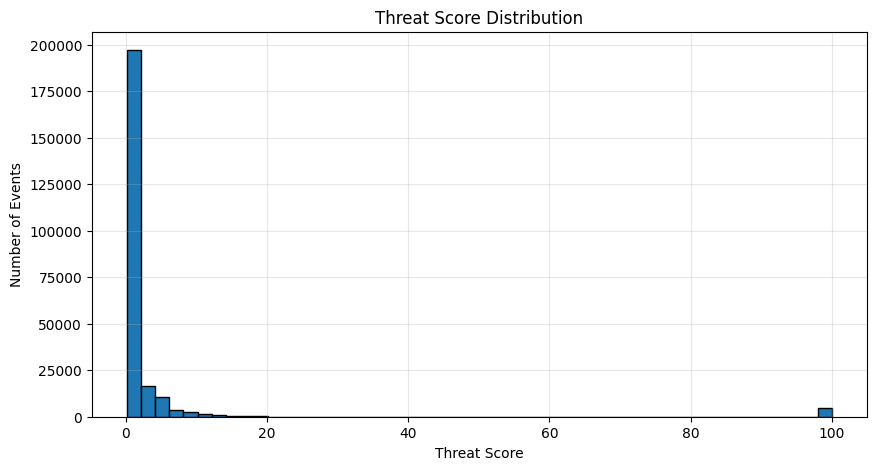

In [31]:
plt.figure(figsize=(10,5))
plt.hist(threat_scores, bins=50, edgecolor="black")
plt.title("Threat Score Distribution")
plt.xlabel("Threat Score")
plt.ylabel("Number of Events")
plt.grid(alpha=0.3)
plt.show()

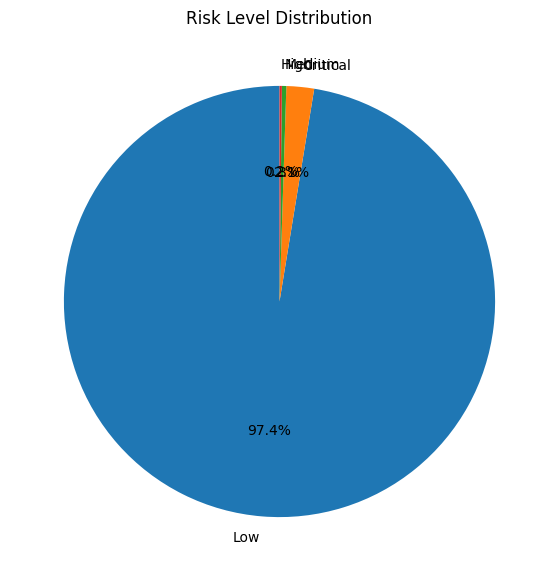

In [32]:
risk_counts = pd.Series(risk_levels).value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Risk Level Distribution")
plt.show()

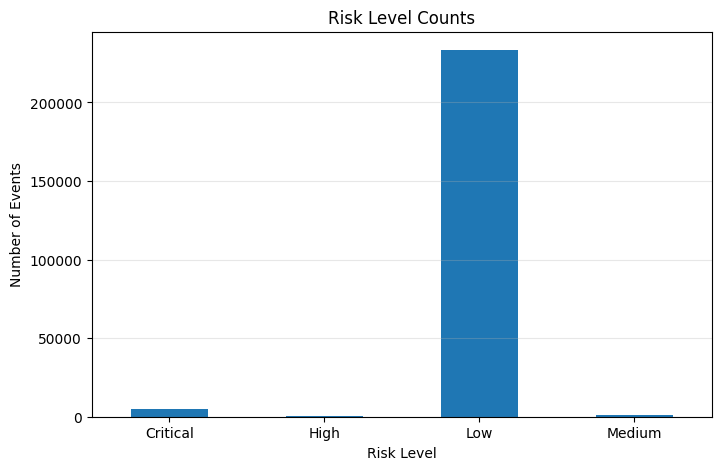

In [33]:
plt.figure(figsize=(8,5))

risk_counts.sort_index().plot(kind="bar")

plt.title("Risk Level Counts")
plt.xlabel("Risk Level")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

In [35]:
print("=" * 60)
print("DeepTrace Threat Scoring Summary")
print("=" * 60)

print(f"Total Events        : {len(threat_report):,}")
print(f"Average Threat Score: {threat_scores.mean():.2f}")
print(f"Maximum Threat Score: {threat_scores.max():.2f}")

print("\nRisk Level Distribution:")

risk_counts = threat_report["RiskLevel"].value_counts()
risk_percent = (risk_counts / len(threat_report) * 100).round(2)

summary = pd.DataFrame({
    "Count": risk_counts,
    "Percentage (%)": risk_percent
})

print(summary)

print("=" * 60)

DeepTrace Threat Scoring Summary
Total Events        : 239,480
Average Threat Score: 3.49
Maximum Threat Score: 100.00

Risk Level Distribution:
            Count  Percentage (%)
RiskLevel                        
Low        233313           97.42
Critical     4951            2.07
Medium        793            0.33
High          423            0.18


In [48]:
threat_report.to_csv(
    "/content/deeptrace_threat_report.csv",
    index=False
)

print("Threat report saved successfully!")

Threat report saved successfully!


In [45]:
import pandas as pd

threat_report = pd.read_csv("/content/deeptrace_threat_report.csv")

threat_report.head()

,GroundTruth,IsolationForest,TransformerPrediction,TransformerProbability,ThreatScore,RiskLevel,Severity,RecommendedAction
0,0,0,0,0.0143,1.43,Low,Informational,Continue monitoring
1,0,1,0,0.0164,6.64,Low,Informational,Continue monitoring
2,0,0,0,0.0234,2.34,Low,Informational,Continue monitoring
3,0,0,0,0.0311,3.11,Low,Informational,Continue monitoring
4,0,0,0,0.0269,2.69,Low,Informational,Continue monitoring


In [38]:
threat_report.tail()

,GroundTruth,IsolationForest,TransformerPrediction,TransformerProbability,ThreatScore,RiskLevel,Severity,RecommendedAction
239475,0,0,0,0.0018,0.18,Low,Informational,Continue monitoring
239476,0,0,0,0.0018,0.18,Low,Informational,Continue monitoring
239477,0,0,0,0.0018,0.18,Low,Informational,Continue monitoring
239478,0,0,0,0.0019,0.19,Low,Informational,Continue monitoring
239479,0,0,0,0.0018,0.18,Low,Informational,Continue monitoring


In [47]:
threat_report.insert(0, "EventID", range(1, len(threat_report) + 1))

# Notebook Summary

In this notebook, a hybrid threat scoring system was developed by combining
Isolation Forest anomaly detection with Transformer-based attack classification.

The notebook successfully:
- Loaded trained models
- Generated anomaly predictions
- Generated Transformer predictions
- Calculated hybrid threat scores
- Classified events into risk levels
- Assigned severity and recommended actions
- Generated a comprehensive threat report
- Visualized threat score and risk level distributions
- Exported the final threat report for downstream alert generation